# 1. Problem Understanding

Business Objective:
An insurance company wants to predict customer insurance premium amount or recommend the best insurance plan based on demographic, lifestyle, and financial information.

This helps the company to:
- Personalize insurance offers
- Reduce customer churn
- Improve premium pricing accuracy

Possible Problem Statements:

Depending on your target variable, the problem can take two main forms:

A. Regression Problem (Predict Premium Amount)
If you have a column like "insurance_premium" (continuous numeric value):
- Predict the insurance premium amount a customer should pay based on their personal and financial details.

B. Classification Problem (Predict Plan Category)
If your target column is "insurance_plan" (Gold, Silver, Bronze):
- Predict the type of insurance plan most suitable for a customer based on their demographic, financial, and medical data.


# A) Insurance Premium Predction
### WorkFlow 

* Problem Understanding
* Data Collection
* Data Cleaning 
* EDA
* Feature Engineering
* Model Building
* Model Evalation
* Front End Back End
* Deployment


In [657]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [658]:
df = pd.read_csv("premiums.csv")
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [659]:
df.shape

(50000, 13)

# Data Cleaning

In [660]:
df.info()

# data types are correct 
# some missing values in smoking_staus , Employmentstatus , Income_Level very less that we can drop those rows
# only 24 row with missing values lets drop them

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    50000 non-null  int64 
 1   Gender                 50000 non-null  object
 2   Region                 50000 non-null  object
 3   Marital_status         50000 non-null  object
 4   Number Of Dependants   50000 non-null  int64 
 5   BMI_Category           50000 non-null  object
 6   Smoking_Status         49989 non-null  object
 7   Employment_Status      49998 non-null  object
 8   Income_Level           49987 non-null  object
 9   Income_Lakhs           50000 non-null  int64 
 10  Medical History        50000 non-null  object
 11  Insurance_Plan         50000 non-null  object
 12  Annual_Premium_Amount  50000 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.0+ MB


* Handling Null Values

In [661]:
df.isnull().any(axis=1).sum()

np.int64(24)

In [662]:
# df[df.isnull().sum(axis=1)>0]

In [663]:
df.dropna(inplace=True)

In [664]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49976 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    49976 non-null  int64 
 1   Gender                 49976 non-null  object
 2   Region                 49976 non-null  object
 3   Marital_status         49976 non-null  object
 4   Number Of Dependants   49976 non-null  int64 
 5   BMI_Category           49976 non-null  object
 6   Smoking_Status         49976 non-null  object
 7   Employment_Status      49976 non-null  object
 8   Income_Level           49976 non-null  object
 9   Income_Lakhs           49976 non-null  int64 
 10  Medical History        49976 non-null  object
 11  Insurance_Plan         49976 non-null  object
 12  Annual_Premium_Amount  49976 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.3+ MB


In [665]:
df.describe()
# df.describe().columns
# Max Age is 356 which is an outlier

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


## Outlier Detction and Handling

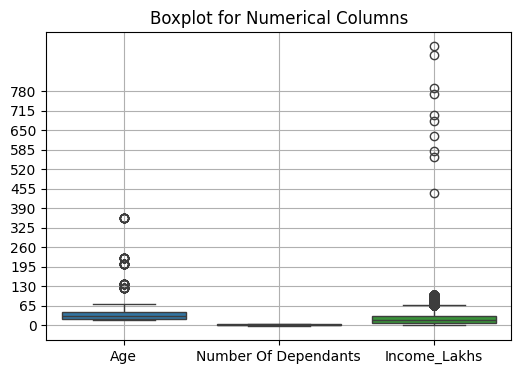

In [666]:
# lets see if there are any outliers in numerical columns
plt.figure(figsize=(6,4))
plt.title("Boxplot for Numerical Columns")

numerical_cols = ['Age', 'Number Of Dependants', 'Income_Lakhs']
sns.boxplot(data=df[numerical_cols])
plt.yticks(range(0, 801, 65))
plt.grid()
plt.show()

# outliers in Age and Income_Lakhs column 


* Data Distribution 

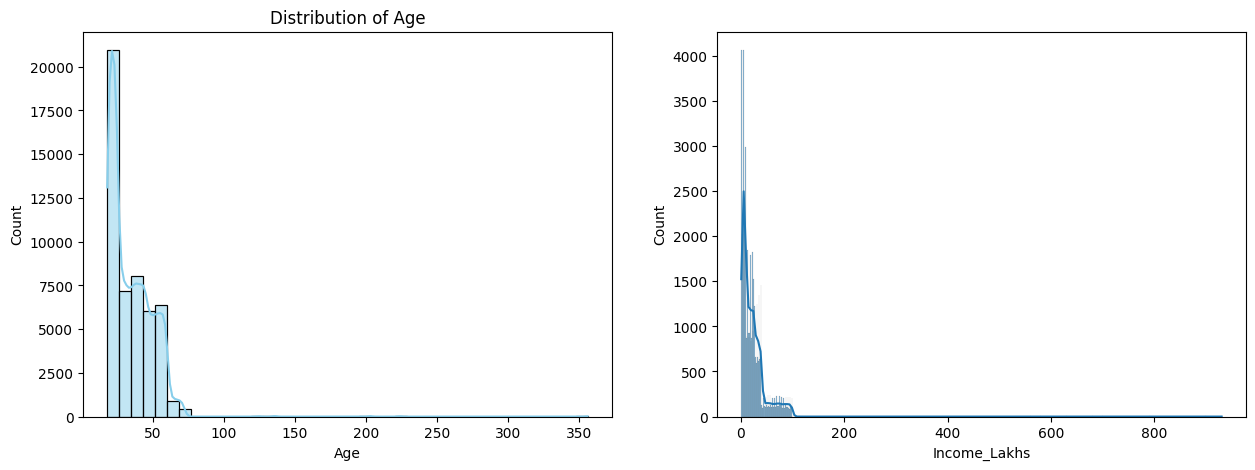

In [667]:
plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
sns.histplot(df['Age'], kde=True, bins = 40 , color='skyblue')
plt.title('Distribution of Age')

plt.subplot(1,2,2)
sns.histplot(df['Income_Lakhs'],kde=True)

plt.show()


* Hence we can conclude that both the fetaures are left skewed 


In [668]:
outlier_age = np.where(df['Age']>75)[0] 
print("Number of Age outliers:", len(outlier_age))


Number of Age outliers: 58


In [669]:
outlier_income = np.where(df['Income_Lakhs']>70)[0]
print('Number of Income outliers',len(outlier_income))

Number of Income outliers 3222


* Let's perform outliers Removal 
1) Perform trimming for Age column since outliers are very less 
2) perfrom Caping on Income_Lakhs Column since outliers are very much 

## Outlier Removal on AGE column 

In [670]:
# Finding IQR 
Q1 = df['Age'] .quantile(0.25)
Q3 = df['Age'] .quantile(0.75)

IQR = Q3 - Q1
IQR

np.float64(23.0)

In [671]:
upper_limit = Q3 + 1.5*IQR
lower_limit = Q1 - 1.5*IQR

In [672]:
print(upper_limit)
print(lower_limit)

79.5
-12.5


In [673]:
out_age =  df[df['Age']>upper_limit]
print(len(out_age))

58


## Trimming

In [674]:
df2 = df[df['Age']<upper_limit]
df2.shape

(49918, 13)

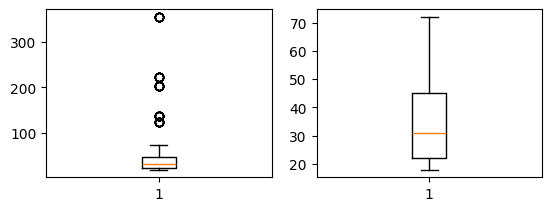

In [675]:
# comparison 
plt.Figure(figsize=(6,4))

plt.subplot(2,2,1)
plt.boxplot(df['Age'])

plt.subplot(2,2,2)
plt.boxplot(df2['Age'])

plt.show()

## Outlier Removal On Income_Lakhs column

In [676]:
df['Income_Lakhs'].describe()

count    49976.000000
mean        23.021150
std         24.221794
min          1.000000
25%          7.000000
50%         17.000000
75%         31.000000
max        930.000000
Name: Income_Lakhs, dtype: float64

In [677]:
Q1 = df['Income_Lakhs'] .quantile(0.25)
Q3 = df['Income_Lakhs'] .quantile(0.75)

IQR = Q3 - Q1
IQR

np.float64(24.0)

In [678]:
lower_limit = Q1 - 1.5* IQR
upper_limit = Q3 + 1.5* IQR

print(lower_limit)
print(upper_limit)

-29.0
67.0


In [679]:
out_income= df[df['Income_Lakhs'] > upper_limit]
print(len(out_income))

3560


## Capping

In [680]:
df3 = df2.copy()
df3['Income_Lakhs'] = np.where(df3['Income_Lakhs']>upper_limit,upper_limit,
                               np.where(
                                   df3['Income_Lakhs']<lower_limit,lower_limit,
                                   df3['Income_Lakhs']
                               ))

df3.shape

(49918, 13)

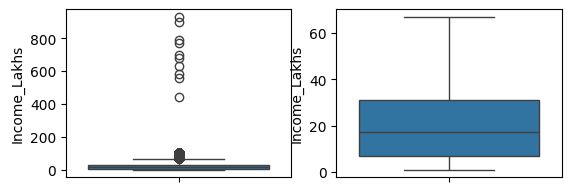

In [681]:
plt.Figure(figsize=(15,15))

plt.subplot(2,2,1)
sns.boxplot(df['Income_Lakhs'])

plt.subplot(2,2,2)
sns.boxplot(df3['Income_Lakhs'])

plt.show()

In [682]:
df3.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,49918.000000,49918.000000,49918.000000,49918.000000
mean,34.401839,1.712168,21.703113,15766.589286
std,13.681600,1.498324,18.929042,8419.137327
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22272.000000
max,72.000000,5.000000,67.000000,43471.000000


* All the outliiers are removed Now 

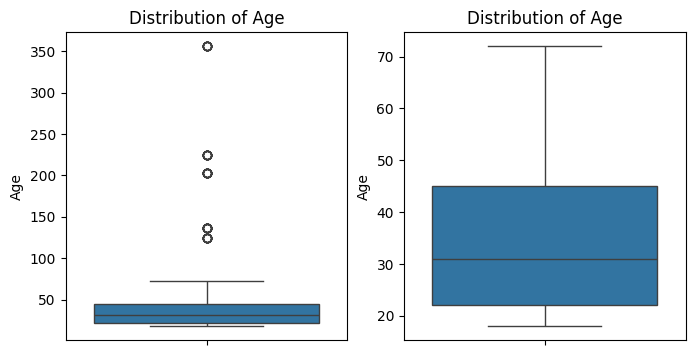

In [683]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
sns.boxplot(df['Age'])
plt.title('Distribution of Age')

plt.subplot(1,2,2)
sns.boxplot(df2['Age'])
plt.title('Distribution of Age')


plt.show()

# Exploratory Data Analysis

In [684]:
df.columns = df.columns.str.strip()
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [685]:
num_features = [f for f in df3.select_dtypes(exclude= 'object')]
cat_features = [f for f in df3.select_dtypes(include= 'object')]

print(f'numeric features: {(num_features)}')
print(f'categorical features: {len(cat_features)}')

numeric features: ['Age', 'Number Of Dependants', 'Income_Lakhs', 'Annual_Premium_Amount']
categorical features: 9


In [686]:
# corr before outlier Handling 
df.corr(numeric_only=True)['Annual_Premium_Amount']

Age                      0.701107
Number Of Dependants     0.412972
Income_Lakhs             0.225314
Annual_Premium_Amount    1.000000
Name: Annual_Premium_Amount, dtype: float64

In [687]:
# corr after outlier Handling 
df3.corr(numeric_only=True)['Annual_Premium_Amount']

Age                      0.767593
Number Of Dependants     0.412869
Income_Lakhs             0.253153
Annual_Premium_Amount    1.000000
Name: Annual_Premium_Amount, dtype: float64

In [688]:
# corr = df3[num_features].corr()
# print(corr)

In [689]:
# plt.figure(figsize=(8, 5))
# sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
# plt.title('Correlation Heatmap of Selected Features')
# plt.show()


# Feature Enggineering 

In [690]:
df3.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6.0,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6.0,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20.0,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,67.0,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,67.0,High blood pressure,Silver,13365


In [691]:
df3[cat_features].nunique()

Gender               2
Region               4
Marital_status       2
BMI_Category         4
Smoking_Status       6
Employment_Status    3
Income_Level         4
Medical History      9
Insurance_Plan       3
dtype: int64

In [692]:
df3['Gender'].value_counts()

Gender
Male      27435
Female    22483
Name: count, dtype: int64

In [693]:
df3['Marital_status'].value_counts()

Marital_status
Unmarried    25635
Married      24283
Name: count, dtype: int64

In [694]:
df3['Gender'] = df3['Gender'].map({'Male': 0, 'Female': 1})
df3['Marital_status'] = df3['Marital_status'].map({'Unmarried': 0, 'Married': 1})


In [695]:
df3.head(1)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,0,Northwest,0,0,Normal,No Smoking,Salaried,<10L,6.0,Diabetes,Bronze,9053


In [696]:
df3['Smoking_Status'].value_counts()

# here we can clube Smoking=0,Not Smoking,Does Not Smoke to No Smoking

Smoking_Status
No Smoking        27328
Regular           15665
Occasional         6903
Smoking=0             8
Not Smoking           8
Does Not Smoke        6
Name: count, dtype: int64

In [697]:
df3['Smoking_Status'] = df3['Smoking_Status'].replace({'Smoking=0' : 'No Smoking',
                                                       'Not Smoking' : 'No Smoking',
                                                       'Does Not Smoke' : 'No Smoking'})


df3['Smoking_Status'].value_counts()

Smoking_Status
No Smoking    27350
Regular       15665
Occasional     6903
Name: count, dtype: int64

In [698]:
df3['Region'].value_counts()

Region
Southeast    17490
Southwest    15126
Northwest    10031
Northeast     7271
Name: count, dtype: int64

In [699]:
df3['BMI_Category'].value_counts()

BMI_Category
Normal         23472
Overweight     11542
Underweight     7753
Obesity         7151
Name: count, dtype: int64

In [700]:
df3['Employment_Status'].value_counts()

Employment_Status
Salaried         20936
Freelancer       15403
Self-Employed    13579
Name: count, dtype: int64

In [701]:
df3['Medical History'].value_counts()

Medical History
No Disease                             21142
Diabetes                                9535
High blood pressure                     7210
Thyroid                                 4919
Heart disease                           2343
Diabetes & High blood pressure          1641
High blood pressure & Heart disease     1273
Diabetes & Thyroid                      1116
Diabetes & Heart disease                 739
Name: count, dtype: int64

In [702]:
df3['Insurance_Plan'].value_counts()

Insurance_Plan
Bronze    21546
Silver    17063
Gold      11309
Name: count, dtype: int64

In [ ]:
df3['Income_Level'].value_counts()

# No need of this columns 

Income_Level
<10L         18643
10L - 25L    14369
25L - 40L    10273
> 40L         6633
Name: count, dtype: int64

In [704]:
df3 = df3.drop('Income_Level', axis=1)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,fe
from sklearn.model_selection import train_test_split

In [706]:
print(df3.columns.tolist())

['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants', 'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Lakhs', 'Medical History', 'Insurance_Plan', 'Annual_Premium_Amount']


In [707]:
x = df3.drop('Annual_Premium_Amount',axis=1)
y = df3['Annual_Premium_Amount']

In [708]:
# Train-Test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)


In [713]:
binary_cols = ['Gender','Marital_status']
num_cols = ['Age', 'Number Of Dependants', 'Income_Lakhs']
cat_cols = x_train.select_dtypes(include='object').columns.tolist()

print(binary_cols)
print(num_cols)
print(cat_cols)


['Gender', 'Marital_status']
['Age', 'Number Of Dependants', 'Income_Lakhs']
['Region', 'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Medical History', 'Insurance_Plan']


In [710]:
df3[cat_cols].nunique()

Region               4
BMI_Category         4
Smoking_Status       3
Employment_Status    3
Medical History      9
Insurance_Plan       3
dtype: int64

In [715]:
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(drop='first',handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num',num_transformer,num_cols),
        ('cat',cat_transformer,cat_cols)
    ], remainder='drop'
)

In [728]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pipe = Pipeline([
    ('preproc', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=1,
        random_state=42
    ))
])

pipe.fit(x_train,y_train)
y_preds = pipe.predict(x_test)

mae = mean_absolute_error(y_test, y_pred=preds)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_preds)
              
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2*100}")

MAE: 811.91
RMSE: 1151.13
R²: 98.12462822062695


# Hyperparameter tunning

In [ ]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# param_grid = {
#     'model__n_estimators': [50, 100, 200],
#     'model__max_depth': [None, 5, 10, 15],
#     'model__min_samples_split': [2, 5, 10],
#     'model__min_samples_leaf': [1, 2, 4]
# }

# grid = GridSearchCV(
#     estimator=pipe,
#     param_grid=param_grid,
#     cv=3,
#     n_jobs=-1,
#     verbose=2,
#     scoring='r2'   
# )

# grid.fit(x_train, y_train)

# print("Best Parameters:", grid.best_params_)
# print("Best CV Score:", grid.best_score_)


# best_model = grid.best_estimator_
# y_pred = best_model.predict(x_test)

# print("\n Test Set Performance:")
# print("R²:", r2_score(y_test, y_pred))
# print("MAE:", mean_absolute_error(y_test, y_pred))



In [729]:
import pickle
with open('insurance_premium_model.pkl', 'wb') as f:
    pickle.dump(pipe, f)

with open('insurance_premium_model.pkl', 'rb') as f:
    model = pickle.load(f)

In [750]:
df3.describe()

,Age,Gender,Marital_status,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,49918.000000,49918.000000,49918.000000,49918.000000,49918.000000,49918.000000
mean,34.401839,0.450399,0.486458,1.712168,21.703113,15766.589286
std,13.681600,0.497539,0.499822,1.498324,18.929042,8419.137327
min,18.000000,0.000000,0.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,0.000000,0.000000,7.000000,8608.000000
50%,31.000000,0.000000,0.000000,2.000000,17.000000,13928.000000
75%,45.000000,1.000000,1.000000,3.000000,31.000000,22272.000000
max,72.000000,1.000000,1.000000,5.000000,67.000000,43471.000000


In [746]:
df3.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Lakhs',
       'Medical History', 'Insurance_Plan', 'Annual_Premium_Amount'],
      dtype='object')

In [751]:
df3['Insurance_Plan'].value_counts()

Insurance_Plan
Bronze    21546
Silver    17063
Gold      11309
Name: count, dtype: int64